In [2]:
#Uploaded the timeseries.cvs file here.
from google.colab import files

uploaded = files.upload()
#upload CSV file

Saving timeseries.csv to timeseries (1).csv


In [3]:
#Read full file
import pandas as pd

df = pd.read_csv('timeseries.csv')
df.head()

,building_id,building_name,device_id,device_name,field,kind,date_time_local,value
0,60b517bd5f7ee717b4903f273,Building 1,60d2ef29cba53c2e21655320,FC_23_29,occupied_mode,Bool,2023-03-14T18:22:01.319+01:00,Occupied
1,60b517bd5f7ee717b4903f273,Building 1,60d2ef29cba53c2e21655320,FC_23_29,zone_air_temperature_sensor,Number,2023-03-14T18:22:01.319+01:00,23.899999618530273
2,60b517bd5f7ee717b4903f273,Building 1,60d2ef29cba53c2e21655320,FC_23_29,effective_cooling_zone_air_temperature_setpoint,Number,2023-03-14T18:22:01.319+01:00,24.0
3,60b517bd5f7ee717b4903f273,Building 1,60d2ef29cba53c2e21655320,FC_23_29,occupied_mode,Bool,2023-03-14T19:00:58.790+01:00,Unoccupied
4,60b517bd5f7ee717b4903f273,Building 1,60d2ef29cba53c2e21655320,FC_23_29,effective_cooling_zone_air_temperature_setpoint,Number,2023-03-14T19:03:29.018+01:00,29.0


In [4]:
#To get the full file description (No of Rows, Col Name, Data Type)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321 entries, 0 to 320
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   building_id      321 non-null    object
 1   building_name    321 non-null    object
 2   device_id        321 non-null    object
 3   device_name      321 non-null    object
 4   field            321 non-null    object
 5   kind             321 non-null    object
 6   date_time_local  321 non-null    object
 7   value            309 non-null    object
dtypes: object(8)
memory usage: 20.2+ KB


In [5]:
#To see all available sensor fields - Need to check this.
df['field'].unique() #field is name of the column
#df['device_name'].unique()

array(['occupied_mode', 'zone_air_temperature_sensor',
       'effective_cooling_zone_air_temperature_setpoint'], dtype=object)

In [6]:
#Converting timeseries.csv file data from rows to column.
prob1_df = df.pivot_table (
    index = 'date_time_local',
    columns='field',
    values='value',
    aggfunc='first'
).reset_index()
prob1_df.head()

field,date_time_local,effective_cooling_zone_air_temperature_setpoint,occupied_mode,zone_air_temperature_sensor
0,2023-03-14T18:22:01.319+01:00,24.0,Occupied,23.899999618530273
1,2023-03-14T18:41:58.555+01:00,NaN,NaN,23.399999618530273
2,2023-03-14T18:59:58.855+01:00,NaN,Unoccupied,NaN
3,2023-03-14T19:00:28.863+01:00,NaN,Unoccupied,NaN
4,2023-03-14T19:00:58.790+01:00,NaN,Unoccupied,NaN


In [7]:
#Check datatype of all
print(type('date_time_local'))
print(type('zone_air_temperature_sensor'))
print(type('effective_cooling_zone_air_temperature_setpoint'))

<class 'str'>
<class 'str'>
<class 'str'>


In [8]:
#Convert Data types
prob1_df['date_time_local'] = pd.to_datetime(
  prob1_df['date_time_local']
)
prob1_df['zone_air_temperature_sensor'] = pd.to_numeric(
   prob1_df['zone_air_temperature_sensor'],
   errors='coerce'
)
prob1_df['effective_cooling_zone_air_temperature_setpoint']= pd.to_numeric(
    prob1_df['effective_cooling_zone_air_temperature_setpoint'],
    errors='coerce'
)
prob1_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 4 columns):
 #   Column                                           Non-Null Count  Dtype                    
---  ------                                           --------------  -----                    
 0   date_time_local                                  59 non-null     datetime64[ns, UTC+01:00]
 1   effective_cooling_zone_air_temperature_setpoint  33 non-null     float64                  
 2   occupied_mode                                    40 non-null     object                   
 3   zone_air_temperature_sensor                      48 non-null     float64                  
dtypes: datetime64[ns, UTC+01:00](1), float64(2), object(1)
memory usage: 2.0+ KB


In [9]:
#Check for missing values
prob1_df.isnull().sum()

,0
field,
date_time_local,0
effective_cooling_zone_air_temperature_setpoint,26
occupied_mode,19
zone_air_temperature_sensor,11


In [10]:
# Remove missing values
prob1_df = prob1_df.dropna()

In [11]:
#Calculate temprature differece

prob1_df['temp_difference'] = (
    prob1_df['zone_air_temperature_sensor']
    -
    prob1_df['effective_cooling_zone_air_temperature_setpoint']
)
prob1_df.head()

field,date_time_local,effective_cooling_zone_air_temperature_setpoint,occupied_mode,zone_air_temperature_sensor,temp_difference
0,2023-03-14 18:22:01.319000+01:00,24.0,Occupied,23.9,-0.1
8,2023-03-14 19:22:33.645000+01:00,29.0,Unoccupied,22.6,-6.4
10,2023-03-14 20:22:41.648000+01:00,29.0,Unoccupied,22.1,-6.9
11,2023-03-14 21:22:49.743000+01:00,29.0,Unoccupied,24.0,-5.0
12,2023-03-14 21:22:49.744000+01:00,29.0,Unoccupied,22.6,-6.4


In [12]:
#Compare Occupied Vs Unoccupied
summary = prob1_df.groupby('occupied_mode')['temp_difference'].agg(
   ['mean','min','max','std','count']

)
summary

,mean,min,max,std,count
occupied_mode,,,,,
Occupied,-1.650000,-3.5,0.000000,1.127749,12
Unoccupied,-5.341176,-8.9,22.299999,7.236890,17


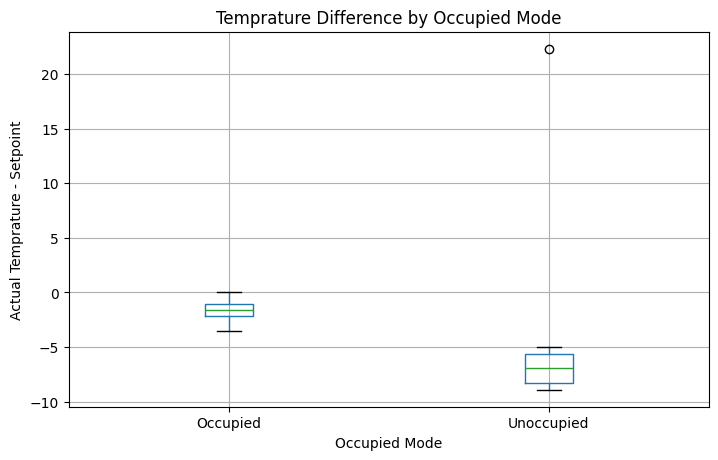

In [13]:
#Create Visualization # 1
import matplotlib.pyplot as plt
prob1_df.boxplot(
    column='temp_difference',
    by='occupied_mode',
    figsize=(8,5)
)
plt.title ('Temprature Difference by Occupied Mode')
plt.suptitle('')
plt.xlabel('Occupied Mode')
plt.ylabel('Actual Temprature - Setpoint')
plt.show()

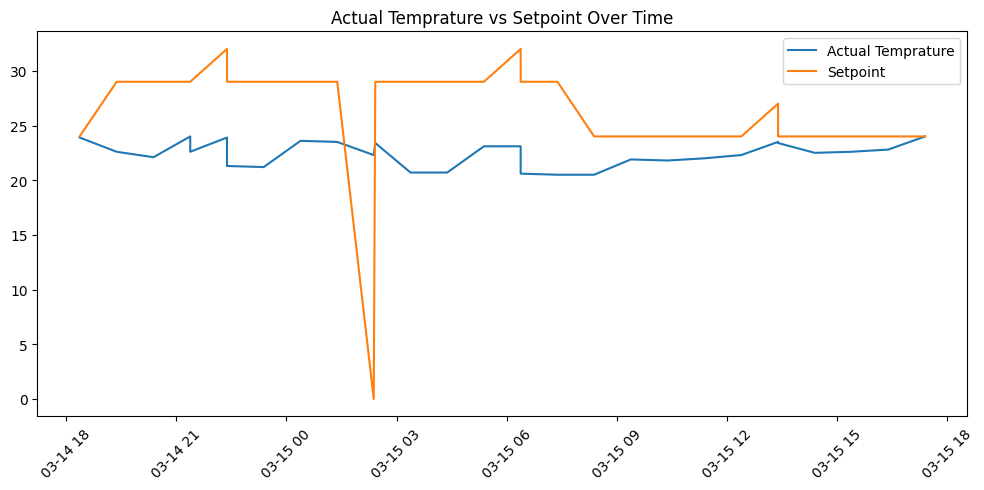

In [14]:
#Create Visualization # 2
plt.figure(figsize=(12,5))
plt.plot(
    prob1_df['date_time_local'],
    prob1_df['zone_air_temperature_sensor'],
    label='Actual Temprature'
)
plt.plot(
    prob1_df['date_time_local'],
    prob1_df['effective_cooling_zone_air_temperature_setpoint'],
    label='Setpoint'
)
plt.legend()
plt.xticks(rotation=45)
plt.title('Actual Temprature vs Setpoint Over Time')
plt.show()

In [16]:
prob1_df = prob1_df.sort_values('date_time_local')

prob1_df['previous_mode'] = prob1_df['occupied_mode'].shift(1)

events=prob1_df[

(prob1_df['previous_mode'] == 'Unoccupied') &
(prob1_df['occupied_mode'] == 'Occupied')

]

events[['date_time_local','previous_mode','occupied_mode']]

field,date_time_local,previous_mode,occupied_mode
36,2023-03-15 08:23:03.481000+01:00,Unoccupied,Occupied


In [17]:

event_start=events.iloc[0]['date_time_local']
print(event_start)

2023-03-15 08:23:03.481000+01:00


In [18]:
#Get all records after the event
after_event = prob1_df[
    prob1_df['date_time_local'] >= event_start
].copy()
after_event.head()

field,date_time_local,effective_cooling_zone_air_temperature_setpoint,occupied_mode,zone_air_temperature_sensor,temp_difference,previous_mode
36,2023-03-15 08:23:03.481000+01:00,24.0,Occupied,20.500000,-3.500000,Unoccupied
42,2023-03-15 09:23:04.386000+01:00,24.0,Occupied,21.900000,-2.100000,Occupied
44,2023-03-15 10:23:05.782000+01:00,24.0,Occupied,21.799999,-2.200001,Occupied
46,2023-03-15 11:23:08.738000+01:00,24.0,Occupied,22.000000,-2.000000,Occupied
49,2023-03-15 12:23:38.123000+01:00,24.0,Occupied,22.299999,-1.700001,Occupied


In [19]:
#Step3 - Define what 'reached setpoint' means

#Create a new column
after_event['within_setpoint'] = (
    abs(
        after_event['zone_air_temperature_sensor']
        -
        after_event['effective_cooling_zone_air_temperature_setpoint']
    ) <= 1

)

In [20]:
#Step4: Check weather the setpoint was reached
after_event[
    ['date_time_local','zone_air_temperature_sensor','effective_cooling_zone_air_temperature_setpoint','within_setpoint']
]


field,date_time_local,zone_air_temperature_sensor,effective_cooling_zone_air_temperature_setpoint,within_setpoint
36,2023-03-15 08:23:03.481000+01:00,20.500000,24.0,False
42,2023-03-15 09:23:04.386000+01:00,21.900000,24.0,False
44,2023-03-15 10:23:05.782000+01:00,21.799999,24.0,False
46,2023-03-15 11:23:08.738000+01:00,22.000000,24.0,False
49,2023-03-15 12:23:38.123000+01:00,22.299999,24.0,False
50,2023-03-15 13:23:39.334000+01:00,23.500000,27.0,False
51,2023-03-15 13:23:39.335000+01:00,23.400000,24.0,True
53,2023-03-15 14:23:43.135000+01:00,22.500000,24.0,False
55,2023-03-15 15:23:48.485000+01:00,22.600000,24.0,False
57,2023-03-15 16:23:51.955000+01:00,22.799999,24.0,False


In [21]:

reached = after_event[
    after_event['within_setpoint'] == True
].iloc[0]

reached_time = (
    reached['date_time_local'] - event_start
)
print ("Reached setpoint at:", reached['date_time_local'])
print ("It took:", reached_time, 'to reach setpoit')

Reached setpoint at: 2023-03-15 13:23:39.335000+01:00
It took: 0 days 05:00:35.854000 to reach setpoit


In [22]:

after_event['within_setpoint'].any()


np.True_

In [23]:

reached = after_event[
    after_event['within_setpoint'] == True
].iloc[0]

reached_time = (
    reached['date_time_local'] - event_start
)

print ("Reached setpoint at:", reached['date_time_local'])
print ("It took:", reached_time, 'to reach setpoit')
print("Event Start Time", event_start)

Reached setpoint at: 2023-03-15 13:23:39.335000+01:00
It took: 0 days 05:00:35.854000 to reach setpoit
Event Start Time 2023-03-15 08:23:03.481000+01:00
